---
title: JJA precipitation across South America (SAAG)
author: Harsha R. Hampapura
date: 2026-06-08
---

## JJA precipitation across South America (SAAG)

This notebook illustrates how to make diagnostic plots using the **WRF-SAAG**
dataset hosted on NCAR's [Geoscience Data Exchange (GDEX)](https://gdex.ucar.edu/datasets/d616000/).

[WRF-SAAG](https://gdex.ucar.edu/datasets/d616000/) is a 4-km, hourly, ~22-year
*convection-permitting* simulation of the **current climate over South America**,
produced by NCAR's Research Applications Laboratory and the South America
Affinity Group by dynamically downscaling ERA5 with the Weather Research and
Forecasting (WRF) model. The historical run spans January 2000 – December 2021
and is described in
[Domínguez et al. (2024, BAMS)](https://doi.org/10.1175/BAMS-D-22-0226.1).

The native data are hourly NetCDF files — roughly **190,000 files** for the full
record — which would be awkward to stream individually. GDEX provides a
[kerchunk](https://fsspec.github.io/kerchunk/) reference layer on top of those
NetCDFs that exposes the entire archive as a single virtual `xarray.Dataset`.
With it, we can slice the 22-year hourly record with a single xarray call and
only stream the bytes we actually need.

## What this notebook does

For one calendar year (2020) we produce a **3-panel map of monthly precipitation
totals for the austral winter (June–July–August)** over South America. We focus
on a single year and season so the workflow stays tractable while still showing
the continent's strong regional precipitation contrasts.

In [9]:
# Imports
import os
import calendar
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

# Dask
from dask_jobqueue import PBSCluster
from dask.distributed import Client

In [10]:
# GDEX kerchunk reference for the SAAG 2D (surface) variables, served over HTTPS
kerchunk_url = "https://data.gdex.ucar.edu/d616000/kerchunk/wrf2d-remote-https.parq"
print(kerchunk_url)

https://data.gdex.ucar.edu/d616000/kerchunk/wrf2d-remote-https.parq


In [11]:
# Set up your scratch folder path
username       = os.environ["USER"]
glade_scratch  = "/glade/derecho/scratch/" + username
print(glade_scratch)

/glade/derecho/scratch/harshah


## Create a PBS cluster

In [12]:
# Create a PBS cluster.
# Each worker must hold the ~5 GB SAAG kerchunk reference in memory, so we use a
# handful of larger-memory (8 GiB) workers rather than many small ones.
cluster = PBSCluster(
    job_name        = "saag-precip",
    cores           = 1,
    memory          = "8GiB",
    processes       = 1,
    local_directory = f"{glade_scratch}/dask/spill/",
    log_directory   = f"{glade_scratch}/dask/logs/",
    resource_spec   = "select=1:ncpus=1:mem=8GB",
    queue           = "casper",
    walltime        = "1:00:00",
    interface       = "ext",)

# Scale the cluster and display the dashboard link
n_workers = 5
client = Client(cluster)
cluster.scale(n_workers)
client.wait_for_workers(n_workers=n_workers)
cluster

/glade/u/home/harshah/.conda/envs/zarr3/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39321 instead
  warnings.warn(


PBSCluster(785a6cd7, 'tcp://128.117.208.119:44333', workers=5, threads=5, memory=40.00 GiB)

## Load SAAG data from GDEX using kerchunk reference files

:::{tip} Finding variable names
The `wrfout` data dictionary lists every variable and its long name. For SAAG it
is available on the [d616000 documentation page](https://gdex.ucar.edu/datasets/d616000/).
:::

### Find the precipitation variable

:::{hint}
WRF output stores grid-scale accumulated precipitation per hourly
output step as `PREC_ACC_NC` (units: mm). Because the output step is hourly,
this is also the hourly precipitation rate in mm hr⁻¹.
:::

### Choosing how to access SAAG

SAAG is published as **hourly NetCDF files** — roughly **190,000 files** for the
full 2000–2021 record. Streaming that many small files individually would be
slow and brittle.

**GDEX adds a [kerchunk](https://fsspec.github.io/kerchunk/) reference layer** on
top of those NetCDFs. A kerchunk reference is a parquet file that records which
byte range of which NetCDF holds each chunk. From the reader's perspective it
looks like a single virtual `xarray.Dataset`, and you only stream the bytes you
actually request.

GDEX publishes two such references for SAAG, each aggregating across **all years**
and **all variables** in its group:

| File                      | Coverage |
|---------------------------|----------|
| `wrf2d-remote-https.parq` | All **2D** (surface) variables — precipitation, 2-m temperature, surface fluxes, … |
| `wrf3d-remote-https.parq` | All **3D** variables — temperature, humidity, wind on model levels |

We want hourly precipitation (`PREC_ACC_NC`), a 2D variable, so we open the
`wrf2d` reference with xarray's kerchunk engine. The result is the full ~22-year
hourly record of every 2D variable in a single Dataset — ready to slice with
`.sel(Time=...)`.

:::{tip} Why use the kerchunk layer
It turns ~190,000 NetCDF files into one virtual store and lets you read only the
chunks that overlap your time/space selection — no per-file loop, no manual
concatenation.
:::

### Load data into xarray

In [13]:
%%time
# One kerchunk reference exposes the full ~22-year hourly 2D archive.
# The first open takes ~30-60 s while kerchunk parses the parquet index;
# subsequent slicing is lazy and fast.
ds = xr.open_dataset(kerchunk_url, engine="kerchunk")

pr    = ds["PREC_ACC_NC"]          # (Time: 192889, south_north: 2027, west_east: 1471)
lat2d = ds["XLAT"].isel(Time=0)    # 2D static lat/lon for plotting + masking
lon2d = ds["XLONG"].isel(Time=0)
pr

CPU times: user 6.37 s, sys: 1.29 s, total: 7.66 s
Wall time: 9.2 s


<xarray.DataArray 'PREC_ACC_NC' (Time: 192889, south_north: 2027,
                                 west_east: 1471)> Size: 2TB
[575140410413 values with dtype=float32]
Coordinates:
  * Time     (Time) datetime64[ns] 2MB 1999-12-31 ... 2022-01-01
    XLAT     (Time, south_north, west_east) float32 2TB ...
    XLONG    (Time, south_north, west_east) float32 2TB ...
Dimensions without coordinates: south_north, west_east
Attributes:
    description:  ACCUMULATED GRID SCALE  PRECIPITATION OVER prec_acc_dt PERI...
    units:        mm
    stagger:       
    long_name:    ACCUMULATED GRID SCALE  PRECIPITATION OVER prec_acc_dt PERI...

## Data Analysis

### Monthly precipitation for austral winter (JJA)

We sum hourly precipitation to monthly totals for June, July, and August of 2020
and lay them out as a 3-panel map. June–August is the **dry season** over much
of tropical South America but the **wet season** along the northern coast and the
southern Andes, so the panels highlight the continent's strong regional contrasts.

:::{note}
This is a single year shown for illustration. To build a climatology, repeat the
reduction over many years and average.
:::

### Compute the seasonal totals

The next cell streams hourly precipitation from GDEX for June, July, and August
2020 and reduces each month to a single grid.

:::{important} Memory and transient failures
The SAAG kerchunk reference is large (~5 GB once parsed) and **each Dask worker
must hold a copy**, so we use a few **8 GiB** workers rather than many small ones.
Reducing one month at a time keeps each worker's memory footprint flat.

If a cell errors with a `ReferenceNotReachable` traceback (a transient GDEX HTTPS
hiccup on one of the underlying NetCDF files), simply **re-run it** — a retry
almost always succeeds.
:::

In [14]:
%%time
# JJA (Jun-Aug) 2020 precipitation: reduce ONE month at a time (memory-safe),
# keeping the three monthly grids in a list for the 3-panel plot below.
pr_2020 = pr.sel(Time="2020")

jja = []
for m in (6, 7, 8):
    pr_m = pr_2020.sel(Time=pr_2020["Time"].dt.month == m).sum("Time").compute()
    jja.append(pr_m)
    print(f"month {m:2d} done")

month  6 done
month  7 done
month  8 done
CPU times: user 49.6 s, sys: 3.03 s, total: 52.6 s
Wall time: 7min 50s


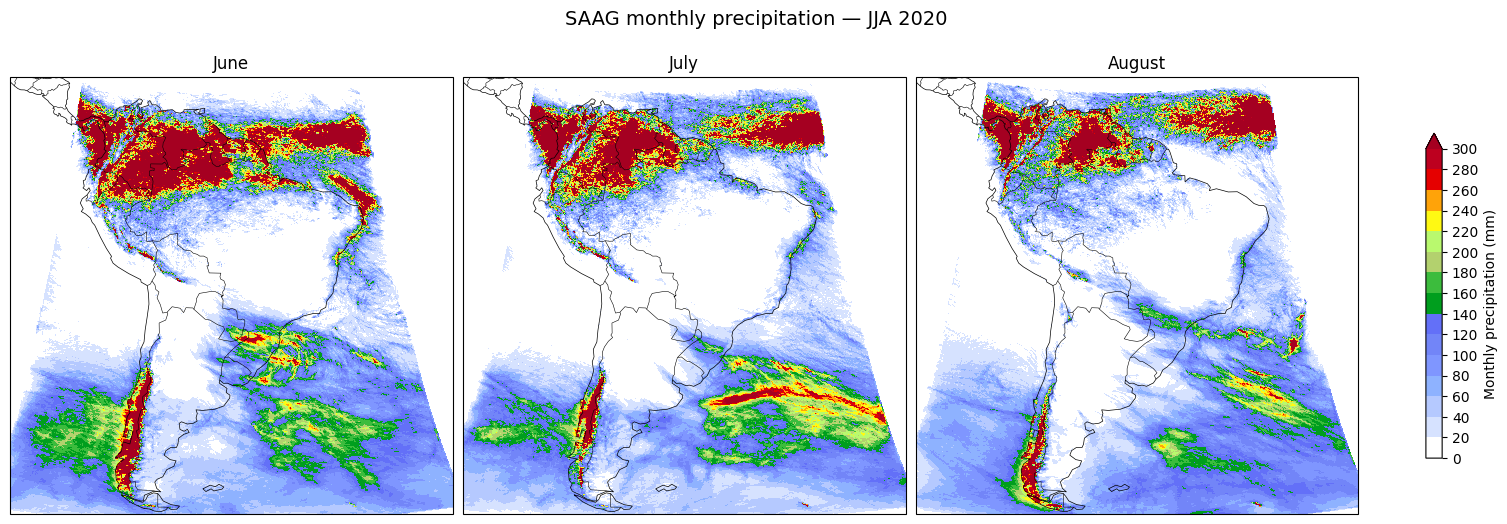

CPU times: user 3.81 s, sys: 155 ms, total: 3.97 s
Wall time: 12.1 s


In [15]:
%%time
proj  = ccrs.PlateCarree()
trans = ccrs.PlateCarree()

# Stack the three monthly grids (June, July, August) into a 'month' dimension
pr_months = xr.concat(jja, dim="month").assign_coords(month=[6, 7, 8])

# Discrete colormap based on the NCL precip3_16lev palette (RGB 0-255)
_rgb255 = [
    (255,255,255), (214,226,255), (181,201,255), (142,178,255),
    (127,150,255), (114,133,248), ( 99,112,248), (  0,158, 30),
    ( 60,188, 61), (179,209,110), (185,249,110), (255,249, 19),
    (255,163,  9), (229,  0,  0), (189,  0, 31), (165,  0, 33),
]
cmap_pr = ListedColormap(np.array(_rgb255) / 255, name="precip3_16lev")
levels  = np.arange(0, 301, 20)        # 0-300 mm monthly total (16 boundaries)
norm    = BoundaryNorm(levels, ncolors=cmap_pr.N, extend="max")

# Coarsen 4x for plotting only (saves cartopy memory)
COARSEN  = 4
pr_plot  = pr_months.coarsen(south_north=COARSEN, west_east=COARSEN, boundary="trim").mean()
lat_plot = lat2d.coarsen(south_north=COARSEN, west_east=COARSEN, boundary="trim").mean()
lon_plot = lon2d.coarsen(south_north=COARSEN, west_east=COARSEN, boundary="trim").mean()

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5.5),
    subplot_kw={"projection": proj},
    constrained_layout=True,
)

for i, ax in enumerate(axes):
    month_int = int(pr_plot.month.values[i])
    im = ax.pcolormesh(
        lon_plot.values, lat_plot.values, pr_plot.isel(month=i).values,
        transform=trans, cmap=cmap_pr, norm=norm, shading="auto",
    )
    ax.add_feature(cfeature.COASTLINE, lw=0.5)
    ax.add_feature(cfeature.BORDERS, lw=0.4)
    ax.add_feature(cfeature.STATES, lw=0.15)
    ax.set_extent([-93, -20, -56, 16], crs=trans)
    ax.set_title(calendar.month_name[month_int], fontsize=12)

cbar = fig.colorbar(
    im, ax=axes, shrink=0.6, orientation="vertical",
    ticks=levels, extend="max",
    label="Monthly precipitation (mm)",
)
fig.suptitle("SAAG monthly precipitation — JJA 2020", fontsize=14, y=1.02)
plt.show()

In [16]:
cluster.close()

## Summary

We accessed the **WRF-SAAG** convection-permitting simulation of South America
through GDEX's kerchunk reference layer, sliced the 2020 austral-winter months
from the ~22-year hourly archive, and reduced June, July, and August each to a
monthly precipitation total — shown as a 3-panel map. June–August is the dry
season across much of tropical South America but the wet season along the
northern coast and the southern Andes, and the panels capture those contrasts.

:::{important} Working with a large kerchunk reference
The SAAG 2D reference is ~5 GB once parsed, and **each Dask worker must hold a
copy** — so we used a handful of larger-memory (8 GiB) workers and reduced one
month at a time to keep each worker's footprint flat.
:::

:::{seealso} References and documentation
- Domínguez et al. (2024), *Advancing South American Water and Climate Science through Multidecadal Convection-Permitting Modeling*, **BAMS**, [doi:10.1175/BAMS-D-22-0226.1](https://doi.org/10.1175/BAMS-D-22-0226.1)
- Dataset: [WRF-SAAG — GDEX d616000](https://gdex.ucar.edu/datasets/d616000/)
:::

To build a precipitation *climatology* rather than a single year, repeat the
monthly reduction over many years and average.